In [2]:
import pandas as pd

df = pd.read_csv("../data/churn_analysis.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (10000, 24)


In [6]:
print("Duplicate rows:", df.duplicated().sum())

print("\nMissing values:")
print(df.isnull().sum())

print("\nChurn distribution:")
print(df["churn"].value_counts())

Duplicate rows: 0

Missing values:
customer_id                     0
company_size                    0
industry                        0
country                         0
plan                            0
contract_type                   0
monthly_recurring_revenue       0
discount_percentage             0
monthly_logins                  0
active_users                    0
monthly_sessions                0
feature_adoption_rate           0
usage_change_pct                0
days_since_last_login           0
onboarding_completion           0
number_of_integrations          0
support_tickets                 0
unresolved_tickets              0
avg_resolution_hours            0
satisfaction_score              0
nps_score                       0
churn                           0
churn_date                   7515
churn_reason                    0
dtype: int64

Churn distribution:
churn
0    7515
1    2485
Name: count, dtype: int64


In [8]:
df.describe().T
df.describe(include="object").T

C:\Users\Administrator\AppData\Local\Temp\ipykernel_21364\464569667.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
company_size,10000,4,Medium,3558
industry,10000,8,Professional Services,1319
country,10000,7,USA,2449
plan,10000,4,Professional,3553
contract_type,10000,3,Monthly,4965
churn_date,2485,1687,2027-09-05,5
churn_reason,10000,9,Not Churned,7515


In [9]:
plan_churn = (
    df.groupby("plan")
      .agg(
          total_customers=("customer_id", "count"),
          churned_customers=("churn", "sum"),
          churn_rate=("churn", "mean")
      )
      .reset_index()
)

plan_churn["churn_rate"] = plan_churn["churn_rate"] * 100

plan_churn

,plan,total_customers,churned_customers,churn_rate
0,Business,2407,545,22.642293
1,Enterprise,1061,275,25.918944
2,Professional,3553,871,24.514495
3,Starter,2979,794,26.653239


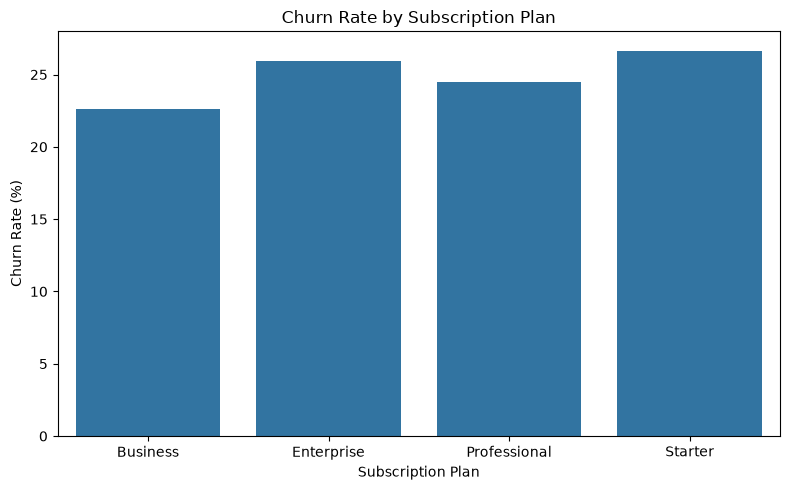

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.barplot(
    data=plan_churn,
    x="plan",
    y="churn_rate"
)

plt.title("Churn Rate by Subscription Plan")
plt.xlabel("Subscription Plan")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [11]:
contract_churn = (
    df.groupby("contract_type")
      .agg(
          total_customers=("customer_id", "count"),
          churned_customers=("churn", "sum"),
          churn_rate=("churn", "mean")
      )
      .reset_index()
)

contract_churn["churn_rate"] = contract_churn["churn_rate"] * 100

contract_churn.sort_values("churn_rate", ascending=False)

,contract_type,total_customers,churned_customers,churn_rate
1,Monthly,4965,1547,31.158107
2,Quarterly,1989,452,22.724987
0,Annual,3046,486,15.955351


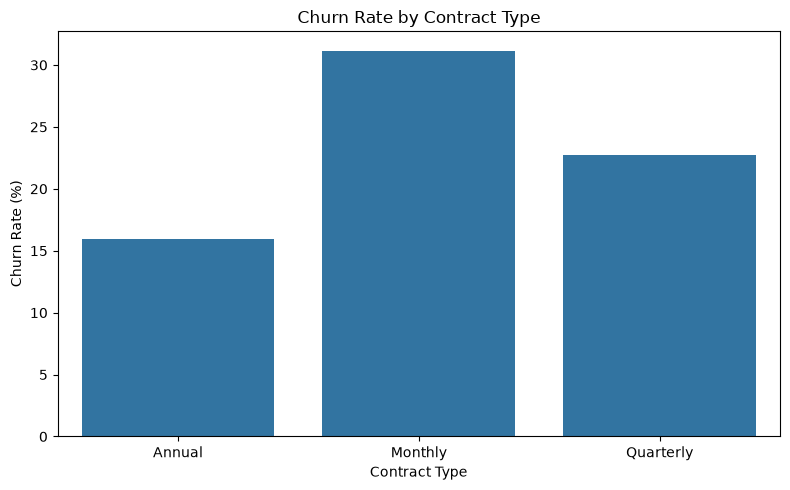

In [12]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=contract_churn,
    x="contract_type",
    y="churn_rate"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

In [13]:
usage_churn = (
    df.groupby("churn")
      .agg(
          avg_logins=("monthly_logins", "mean"),
          avg_active_users=("active_users", "mean"),
          avg_sessions=("monthly_sessions", "mean"),
          avg_feature_adoption=("feature_adoption_rate", "mean"),
          avg_usage_change=("usage_change_pct", "mean"),
          avg_days_since_login=("days_since_last_login", "mean"),
          avg_onboarding=("onboarding_completion", "mean")
      )
      .round(2)
)

usage_churn.index = ["Active", "Churned"]

usage_churn

,avg_logins,avg_active_users,avg_sessions,avg_feature_adoption,avg_usage_change,avg_days_since_login,avg_onboarding
Active,58.88,16.87,64.45,64.05,1.15,18.38,77.91
Churned,59.71,16.89,66.01,53.65,-4.86,23.03,74.35


In [14]:
support_churn = (
    df.groupby("churn")
      .agg(
          avg_support_tickets=("support_tickets", "mean"),
          avg_unresolved_tickets=("unresolved_tickets", "mean"),
          avg_resolution_hours=("avg_resolution_hours", "mean"),
          avg_satisfaction=("satisfaction_score", "mean"),
          avg_nps=("nps_score", "mean")
      )
      .round(2)
)

support_churn.index = ["Active", "Churned"]

support_churn

,avg_support_tickets,avg_unresolved_tickets,avg_resolution_hours,avg_satisfaction,avg_nps
Active,2.36,0.57,24.81,7.13,38.23
Churned,2.91,0.83,24.55,6.74,31.37


In [15]:
revenue_analysis = (
    df.groupby("churn")
      .agg(
          customers=("customer_id", "count"),
          total_mrr=("monthly_recurring_revenue", "sum")
      )
      .reset_index()
)

revenue_analysis["churn_status"] = revenue_analysis["churn"].map({
    0: "Active",
    1: "Churned"
})

revenue_analysis["total_mrr"] = revenue_analysis["total_mrr"].round(2)

revenue_analysis

,churn,customers,total_mrr,churn_status
0,0,7515,4634812.72,Active
1,1,2485,1507914.69,Churned


In [16]:
total_mrr = df["monthly_recurring_revenue"].sum()
churned_mrr = df.loc[df["churn"] == 1, "monthly_recurring_revenue"].sum()

mrr_percentage = (churned_mrr / total_mrr) * 100

print(f"Total MRR: ₹{total_mrr:,.2f}")
print(f"MRR associated with churned customers: ₹{churned_mrr:,.2f}")
print(f"Percentage: {mrr_percentage:.2f}%")

Total MRR: ₹6,142,727.41
MRR associated with churned customers: ₹1,507,914.69
Percentage: 24.55%


In [17]:
mrr_by_plan = (
    df.groupby("plan")
      .agg(
          customers=("customer_id", "count"),
          churned_customers=("churn", "sum"),
          total_mrr=("monthly_recurring_revenue", "sum"),
          churned_mrr=("monthly_recurring_revenue", lambda x: x[df.loc[x.index, "churn"] == 1].sum())
      )
      .reset_index()
)

mrr_by_plan["churned_mrr_percentage"] = (
    mrr_by_plan["churned_mrr"] / mrr_by_plan["total_mrr"] * 100
).round(2)

mrr_by_plan.round(2).sort_values("churned_mrr", ascending=False)

,plan,customers,churned_customers,total_mrr,churned_mrr,churned_mrr_percentage
1,Enterprise,1061,275,2399171.42,625074.92,26.05
0,Business,2407,545,2101577.23,473313.13,22.52
2,Professional,3553,871,1274632.38,311132.93,24.41
3,Starter,2979,794,367346.38,98393.71,26.78


In [18]:
churn_reasons = (
    df[df["churn"] == 1]
    .groupby("churn_reason")
    .agg(
        churned_customers=("customer_id", "count"),
        churned_mrr=("monthly_recurring_revenue", "sum")
    )
    .reset_index()
)

churn_reasons["customer_percentage"] = (
    churn_reasons["churned_customers"]
    / churn_reasons["churned_customers"].sum()
    * 100
).round(2)

churn_reasons.sort_values(
    "churned_customers",
    ascending=False
)

,churn_reason,churned_customers,churned_mrr,customer_percentage
0,Business Closure,541,314202.92,21.77
2,Contract Expired,521,300560.07,20.97
7,Poor User Experience,510,301889.86,20.52
1,Competitor,497,277835.25,20.00
3,High Price,132,126309.74,5.31
4,Low Product Usage,124,85080.37,4.99
6,Poor Support,88,63587.65,3.54
5,Missing Features,72,38448.83,2.90


In [19]:
df_ml = df.copy()

In [20]:
df_ml["engagement_score"] = (
    df_ml["feature_adoption_rate"] * 0.4
    + df_ml["onboarding_completion"] * 0.3
    + (100 - df_ml["days_since_last_login"].clip(upper=100)) * 0.2
    + (df_ml["usage_change_pct"].clip(-100, 100) + 100) / 2 * 0.1
)

In [21]:
df_ml["support_risk"] = (
    df_ml["unresolved_tickets"] > 0
).astype(int)

In [22]:
df_ml[
    [
        "customer_id",
        "feature_adoption_rate",
        "usage_change_pct",
        "days_since_last_login",
        "onboarding_completion",
        "engagement_score",
        "unresolved_tickets",
        "support_risk",
        "churn"
    ]
].head(10)

,customer_id,feature_adoption_rate,usage_change_pct,days_since_last_login,onboarding_completion,engagement_score,unresolved_tickets,support_risk,churn
0,10001,88.1,-38.5,0,87.6,84.595,0,0,0
1,10002,17.1,-1.7,0,97.4,60.975,0,0,0
2,10003,80.7,-27.2,41,72.5,69.470,1,1,0
3,10004,73.9,22.6,32,86.7,75.300,0,0,0
4,10005,29.8,10.1,0,24.7,44.835,0,0,1
5,10006,68.4,-21.0,44,76.3,65.400,0,0,1
6,10007,67.2,-43.6,17,71.5,67.750,0,0,1
7,10008,54.6,9.9,20,75.8,66.075,1,1,0
8,10009,68.8,-30.8,32,69.9,65.550,1,1,1
9,10010,69.6,1.4,0,69.9,73.880,1,1,1


In [23]:
from sklearn.model_selection import train_test_split

X = df_ml.drop(
    columns=[
        "customer_id",
        "churn",
        "churn_date",
        "churn_reason"
    ]
)

y = df_ml["churn"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (10000, 22)
Target: (10000,)


In [24]:
categorical_columns = X.select_dtypes(include=["object", "str"]).columns.tolist()
numeric_columns = X.select_dtypes(exclude=["object", "str"]).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

print("\nNumeric columns:")
print(numeric_columns)

Categorical columns:
['company_size', 'industry', 'country', 'plan', 'contract_type']

Numeric columns:
['monthly_recurring_revenue', 'discount_percentage', 'monthly_logins', 'active_users', 'monthly_sessions', 'feature_adoption_rate', 'usage_change_pct', 'days_since_last_login', 'onboarding_completion', 'number_of_integrations', 'support_tickets', 'unresolved_tickets', 'avg_resolution_hours', 'satisfaction_score', 'nps_score', 'engagement_score', 'support_risk']


In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        ),
        (
            "numeric",
            "passthrough",
            numeric_columns
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining churn rate:", round(y_train.mean() * 100, 2), "%")
print("Testing churn rate:", round(y_test.mean() * 100, 2), "%")

Training samples: 8000
Testing samples: 2000

Training churn rate: 24.85 %
Testing churn rate: 24.85 %


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


c:\Users\Administrator\Desktop\Saas Customer churn intelligence\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_split=10,
            min_samples_leaf=4,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [ ]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("Recall   :", round(recall_score(y_test, y_pred_rf), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_rf), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_rf), 4))

In [31]:
from xgboost import XGBClassifier

xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

xgb_model.fit(X_train, y_train)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [ ]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred_xgb), 4))
print("Precision:", round(precision_score(y_test, y_pred_xgb), 4))
print("Recall   :", round(recall_score(y_test, y_pred_xgb), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_xgb), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_xgb), 4))

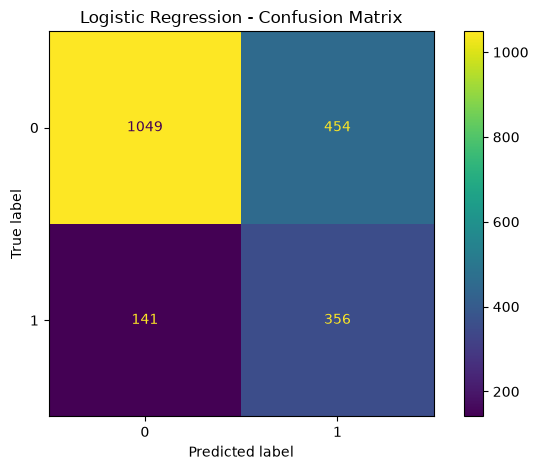

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

In [34]:
risk_df = X_test.copy()

risk_df["customer_id"] = df_ml.loc[X_test.index, "customer_id"]
risk_df["actual_churn"] = y_test
risk_df["churn_probability"] = y_prob

risk_df["risk_level"] = pd.cut(
    risk_df["churn_probability"],
    bins=[0, 0.30, 0.60, 1.00],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

risk_df["monthly_recurring_revenue"] = df_ml.loc[
    X_test.index,
    "monthly_recurring_revenue"
]

risk_df = risk_df[
    [
        "customer_id",
        "monthly_recurring_revenue",
        "actual_churn",
        "churn_probability",
        "risk_level"
    ]
]

risk_df.head(10)

,customer_id,monthly_recurring_revenue,actual_churn,churn_probability,risk_level
5481,15482,2251.47,0,0.103278,Low
3493,13494,140.01,1,0.601793,High
7275,17276,913.29,0,0.512207,Medium
8037,18038,130.29,1,0.771655,High
8530,18531,121.82,1,0.619718,High
4517,14518,389.34,0,0.306603,Medium
965,10966,375.07,0,0.198761,Low
8975,18976,141.50,1,0.569284,Medium
2914,12915,329.58,1,0.875074,High
9257,19258,107.30,0,0.358176,Medium


In [35]:
risk_df["risk_level"].value_counts()

risk_level
Medium    878
Low       576
High      546
Name: count, dtype: int64

In [36]:
risk_df.groupby("risk_level")["monthly_recurring_revenue"].sum().round(2)

risk_level
Low       337454.02
Medium    509832.84
High      331388.70
Name: monthly_recurring_revenue, dtype: float64

In [37]:
risk_df["predicted_mrr_at_risk"] = (
    risk_df["monthly_recurring_revenue"]
    * risk_df["churn_probability"]
)

total_predicted_mrr_at_risk = (
    risk_df["predicted_mrr_at_risk"].sum()
)

print(
    f"Predicted MRR at Risk: "
    f"₹{total_predicted_mrr_at_risk:,.2f}"
)

Predicted MRR at Risk: ₹536,687.88


In [38]:
active_risk = risk_df[risk_df["actual_churn"] == 0].copy()

active_predicted_mrr_at_risk = (
    active_risk["monthly_recurring_revenue"]
    * active_risk["churn_probability"]
).sum()

print(
    f"Predicted MRR at Risk among active customers: "
    f"₹{active_predicted_mrr_at_risk:,.2f}"
)

Predicted MRR at Risk among active customers: ₹358,015.39


In [40]:
# Extract the fitted preprocessing and Logistic Regression model
fitted_preprocessor = logistic_model.named_steps["preprocessor"]
logistic_classifier = logistic_model.named_steps["model"]

# Transform the test data
X_test_transformed = fitted_preprocessor.transform(X_test)

# Get feature names after one-hot encoding
feature_names = fitted_preprocessor.get_feature_names_out()

print("Transformed shape:", X_test_transformed.shape)
print("Number of feature names:", len(feature_names))

Transformed shape: (2000, 43)
Number of feature names: 43


In [41]:
explainer = shap.LinearExplainer(
    logistic_classifier,
    fitted_preprocessor.transform(X_train)
)

shap_values = explainer(X_test_transformed)

print("SHAP analysis completed!")

Background dataset has 8000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=8000 when initializing the masker.


SHAP analysis completed!


In [ ]:
import numpy as np

shap_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": np.abs(shap_values.values).mean(axis=0)
})

shap_importance = (
    shap_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

shap_importance.head(15)

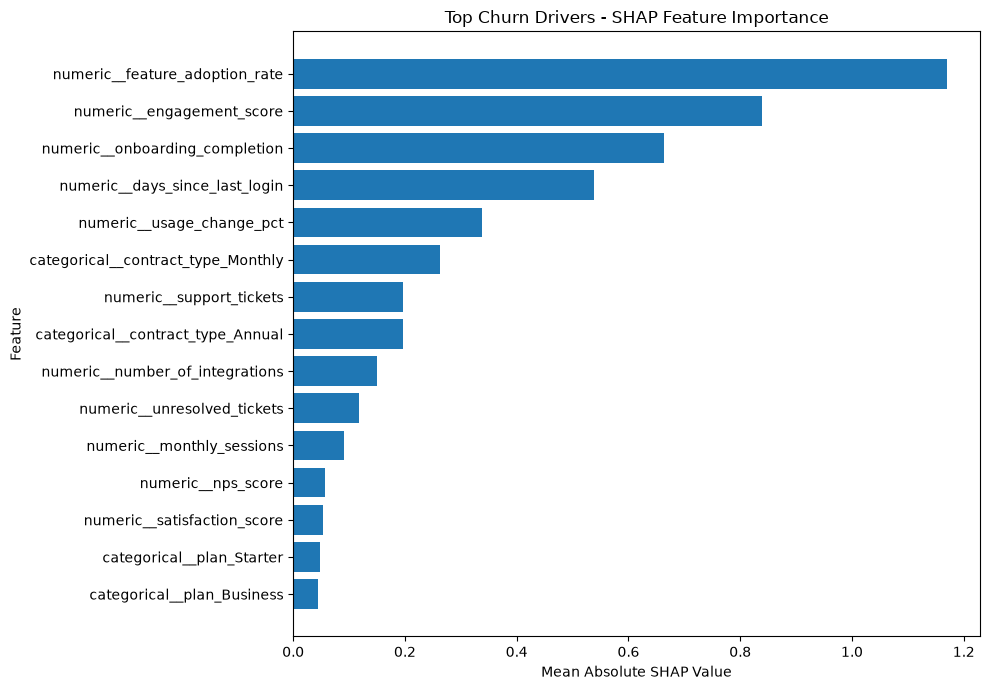

In [43]:
plt.figure(figsize=(10, 7))

top_features = shap_importance.head(15).sort_values("importance")

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.title("Top Churn Drivers - SHAP Feature Importance")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

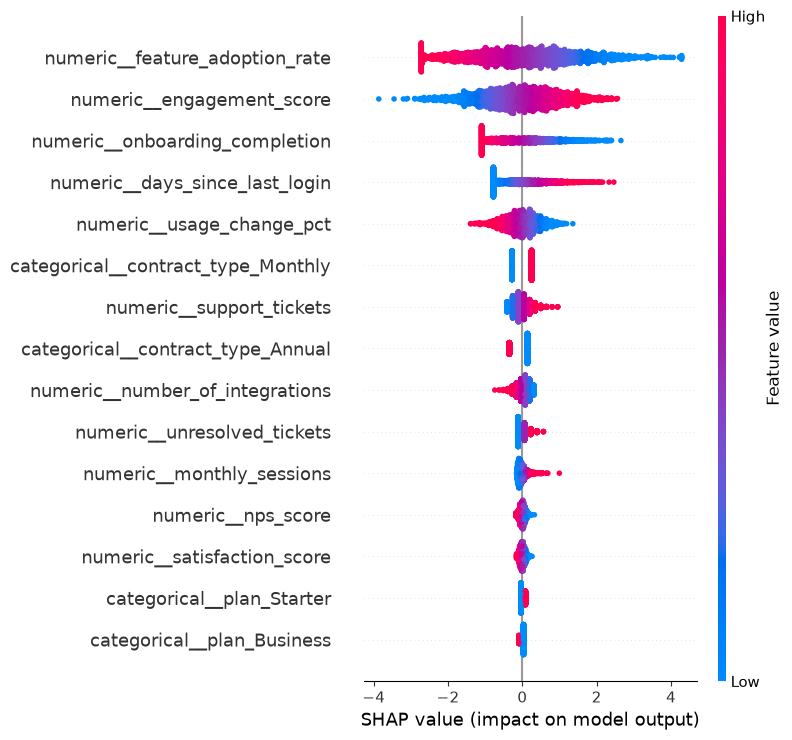

In [44]:
shap.summary_plot(
    shap_values.values,
    X_test_transformed,
    feature_names=feature_names,
    max_display=15
)

In [45]:
retention_df = risk_df.merge(
    df_ml[
        [
            "customer_id",
            "feature_adoption_rate",
            "usage_change_pct",
            "unresolved_tickets",
            "onboarding_completion"
        ]
    ],
    on="customer_id",
    how="left"
)

def recommend_action(row):
    if row["feature_adoption_rate"] < 50:
        return "Feature Adoption Campaign"
    
    elif row["usage_change_pct"] < -10:
        return "Re-engagement Campaign"
    
    elif row["unresolved_tickets"] > 0:
        return "Priority Support"
    
    elif row["onboarding_completion"] < 60:
        return "Onboarding Intervention"
    
    else:
        return "Customer Success Review"


retention_df["recommended_action"] = retention_df.apply(
    recommend_action,
    axis=1
)

retention_df.head(10)

,customer_id,monthly_recurring_revenue,actual_churn,churn_probability,risk_level,predicted_mrr_at_risk,feature_adoption_rate,usage_change_pct,unresolved_tickets,onboarding_completion,recommended_action
0,15482,2251.47,0,0.103278,Low,232.528217,69.3,33.1,0,76.6,Customer Success Review
1,13494,140.01,1,0.601793,High,84.257096,72.2,-18.8,1,72.4,Re-engagement Campaign
2,17276,913.29,0,0.512207,Medium,467.793182,40.4,-38.8,1,53.0,Feature Adoption Campaign
3,18038,130.29,1,0.771655,High,100.538930,73.8,-33.8,0,64.2,Re-engagement Campaign
4,18531,121.82,1,0.619718,High,75.494002,49.2,-15.2,0,63.5,Feature Adoption Campaign
5,14518,389.34,0,0.306603,Medium,119.372697,45.8,25.9,1,70.3,Feature Adoption Campaign
6,10966,375.07,0,0.198761,Low,74.549392,85.8,1.9,0,89.8,Customer Success Review
7,18976,141.50,1,0.569284,Medium,80.553734,30.0,39.6,2,88.9,Feature Adoption Campaign
8,12915,329.58,1,0.875074,High,288.407007,44.2,0.1,1,30.3,Feature Adoption Campaign
9,19258,107.30,0,0.358176,Medium,38.432337,65.8,27.8,0,51.2,Onboarding Intervention


In [ ]:
retention_df["recommended_action"].value_counts()

In [ ]:
active_retention_df = retention_df[
    retention_df["actual_churn"] == 0
].copy()

active_retention_df = active_retention_df.sort_values(
    "churn_probability",
    ascending=False
)

print("Active customers in test set:", len(active_retention_df))
print(
    "Predicted MRR at Risk: ₹",
    round(
        active_retention_df["predicted_mrr_at_risk"].sum(),
        2
    )
)

active_retention_df.head(10)

In [ ]:
active_retention_df[
    [
        "customer_id",
        "monthly_recurring_revenue",
        "churn_probability",
        "risk_level",
        "predicted_mrr_at_risk",
        "feature_adoption_rate",
        "usage_change_pct",
        "unresolved_tickets",
        "onboarding_completion",
        "recommended_action"
    ]
].head(10)

In [49]:
output_path = "../data/customer_risk_predictions.csv"

active_retention_df.to_csv(
    output_path,
    index=False
)

print("File exported successfully!")
print("Saved to:", output_path)
print("Rows:", len(active_retention_df))

File exported successfully!
Saved to: ../data/customer_risk_predictions.csv
Rows: 1503
